<a href="https://colab.research.google.com/github/qndks11/MNIST/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 모듈 다운로드

In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

BATCH_SIZE = 32
EPOCHS = 25

# 데이터 다운로드하기

In [ ]:
# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor()])

# 트레이닝 데이터 다운로드
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# 테스트 데이터 다운로드
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size = BATCH_SIZE, shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size = BATCH_SIZE, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.28MB/s]


# CNN 모델

In [ ]:
class CNN(torch.nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1)
    self.conv2 = torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1)
    self.pool = torch.nn.MaxPool2d(kernel_size=2)
    self.relu = torch.nn.ReLU(inplace=True)

    self.fc1 = torch.nn.Linear(32*5*5, 64)
    self.fc2 = torch.nn.Linear(64, 10)

  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)
    x = self.conv2(x)
    x = self.relu(x)
    x = self.pool(x)

    x = x.view(x.size(0), -1)
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x

# 학습

In [ ]:
model = CNN().to(DEVICE)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model.train()

for epoch in range(EPOCHS):
  running_loss = 0.0

  for images, labels in train_loader:
    images, labels = images.to(DEVICE), labels.to(DEVICE)

    optimizer.zero_grad()              # 그레디언트 초기화
    outputs = model(images)            # Forward
    loss = criterion(outputs, labels)  # loss 계산
    loss.backward()                    # Backward
    optimizer.step()                   # 가중치 업데이트

    running_loss += loss.item()

  avg_loss = running_loss / len(train_loader)
  print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}")

Epoch [1/25], Loss: 0.1861
Epoch [2/25], Loss: 0.0592
Epoch [3/25], Loss: 0.0421
Epoch [4/25], Loss: 0.0327
Epoch [5/25], Loss: 0.0272
Epoch [6/25], Loss: 0.0206
Epoch [7/25], Loss: 0.0186
Epoch [8/25], Loss: 0.0157
Epoch [9/25], Loss: 0.0135
Epoch [10/25], Loss: 0.0117
Epoch [11/25], Loss: 0.0100
Epoch [12/25], Loss: 0.0101
Epoch [13/25], Loss: 0.0082
Epoch [14/25], Loss: 0.0081
Epoch [15/25], Loss: 0.0054
Epoch [16/25], Loss: 0.0072
Epoch [17/25], Loss: 0.0062
Epoch [18/25], Loss: 0.0058
Epoch [19/25], Loss: 0.0055
Epoch [20/25], Loss: 0.0057
Epoch [21/25], Loss: 0.0047
Epoch [22/25], Loss: 0.0055
Epoch [23/25], Loss: 0.0039
Epoch [24/25], Loss: 0.0042
Epoch [25/25], Loss: 0.0041


# 평가

In [ ]:
model.eval()

correct = 0
total = 0

# 틀린 예측 모으기
wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
  for images, labels in test_loader:
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item() # 맞춘 개수가 나옴
    mask = predicted != labels
    wrong_images.extend(images[mask].cpu())
    wrong_preds.extend(predicted[mask].cpu())
    wrong_labels.extend(labels[mask].cpu())

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.05%


## 틀린 이미지 표시하기

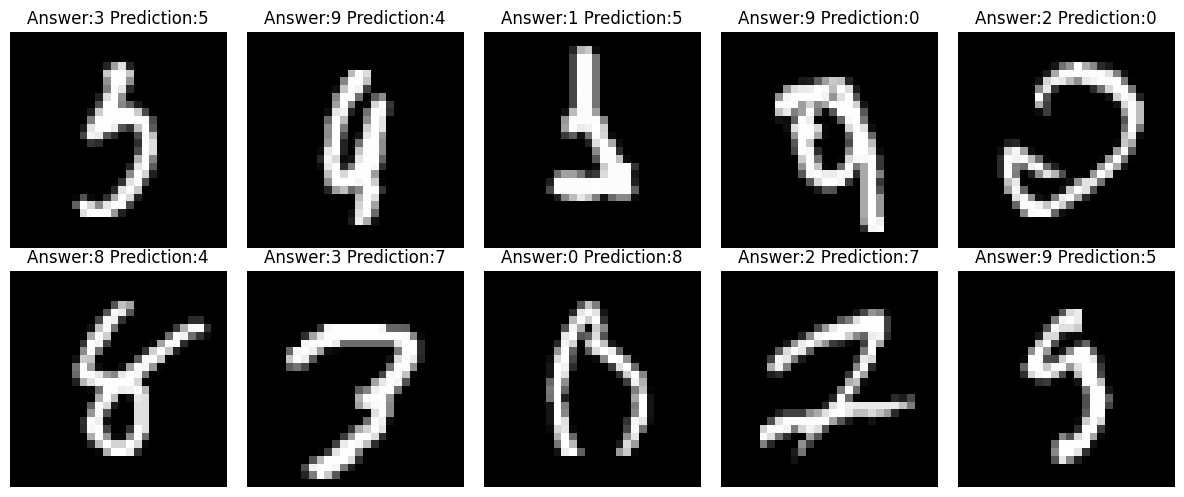

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    if i >= len(wrong_images):
        break
    img = wrong_images[i].squeeze()  # (1,28,28) -> (28,28)
    ax.imshow(img, cmap='gray') # imshow는 기본적으로 컬러맵을 적용
    ax.set_title(f"Answer:{wrong_labels[i].item()} Prediction:{wrong_preds[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()
